<a href="https://colab.research.google.com/github/shireesha-palakurla/Plant_Disease_Detection/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Extract Dataset from ZIP File**

In [55]:
import zipfile

zip_path = '/content/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print('Dataset Extracted Successfully')

Dataset Extracted Successfully


**Install Libraries**

In [56]:
pip install tensorflow opencv-python matplotlib

**Import Libraries**

In [57]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

**Set Dataset Path**

In [58]:
dataset_path = "/content/dataset/PlantVillage"

print(os.listdir(dataset_path))

['Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Pepper__bell___Bacterial_spot', 'Potato___Early_blight', 'Tomato__Target_Spot', 'Tomato_Leaf_Mold', 'Tomato_Late_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_healthy', 'Tomato_Early_blight', 'Tomato_Bacterial_spot', 'Pepper__bell___healthy', 'Tomato__Tomato_mosaic_virus']


**Create Image Generator**

In [59]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

**Training Generator**

In [60]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 16516 images belonging to 15 classes.


**Validation Generator**

In [61]:
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4122 images belonging to 15 classes.


**Build CNN Model**

In [62]:
model = Sequential()

# Layer 1
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3) # Corrected input_shape
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    train_generator.num_classes,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile Model**

In [63]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [64]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [65]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 591s 1s/step - accuracy: 0.5075 - loss: 1.5439 - val_accuracy: 0.6827 - val_loss: 0.9242
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.6921 - loss: 0.9347 - val_accuracy: 0.8273 - val_loss: 0.5556
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.7533 - loss: 0.7323 - val_accuracy: 0.8270 - val_loss: 0.5061
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 573s 1s/step - accuracy: 0.7911 - loss: 0.6127 - val_accuracy: 0.8785 - val_loss: 0.3824
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 576s 1s/step - accuracy: 0.8230 - loss: 0.5138 - val_accuracy: 0.8772 - val_loss: 0.3888


**Save Model**

In [66]:
model.save('plant_disease_model.h5')

print('Model Saved Successfully')

Model Saved Successfully


**Accuracy Graph**

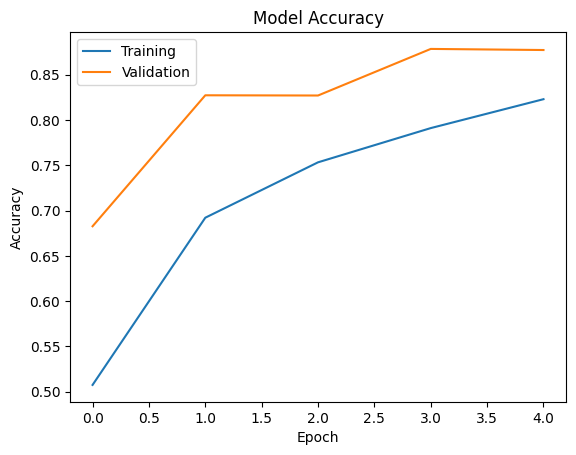

In [67]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training','Validation'])

plt.show()

**Upload Test Image**

In [68]:
from google.colab import files

uploaded = files.upload()

Saving early blight.jfif to early blight.jfif


**Preprocess Image**

In [69]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255

**Predict Disease**

In [70]:
prediction = model.predict(img_array)

class_indices = train_generator.class_indices

classes = list(class_indices.keys())

result = classes[np.argmax(prediction)]

print("Predicted Disease:")
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted Disease:
Tomato_Late_blight


**Display Result**

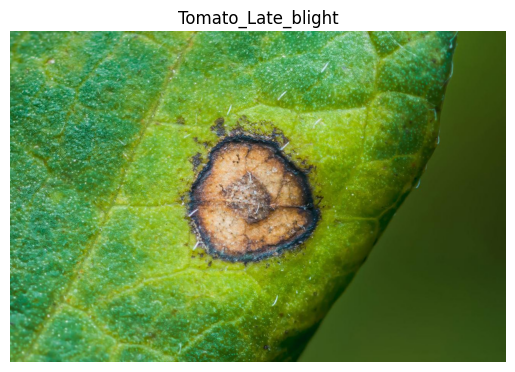

In [71]:
plt.imshow(image.load_img(img_path))
plt.title(result)
plt.axis('off')
plt.show()